In [ ]:
!pip install rdkit PyTDC scikit-learn xgboost pandas matplotlib -q

In [ ]:
from tdc.multi_pred import DTI
data = DTI(name='DAVIS')
df = data.get_data()
print(df.shape)
df.head()

Found local copy...
Loading...
Done!


(25772, 5)


,Drug_ID,Drug,Target_ID,Target,Y
0,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,AAK1,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...,43.0
1,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ABL1p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,10000.0
2,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ABL2,MVLGTVLLPPNSYGRDQDTSLCCLCTEASESALPDLTDHFASCVED...,10000.0
3,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ACVR1,MVDGVMILPVLIMIALPSPSMEDEKPKVNPKLYMCVCEGLSCGNED...,10000.0
4,11314340,Cc1[nH]nc2ccc(-c3cncc(OCC(N)Cc4ccccc4)c3)cc12,ACVR1B,MAESAGASSFFPLVVLLLAGSGGSGPRGVQALLCACTSCLQANYTC...,10000.0


In [ ]:
split = data.get_split(method='cold_split', column_name='Drug')
train = split['train']
valid = split['valid']
test = split['test']

print("Train size:", train.shape)
print("Valid size:", valid.shape)
print("Test size:", test.shape)

Train size: (17813, 5)
Valid size: (2653, 5)
Test size: (5306, 5)


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    return np.array(fp)

# Test it on one molecule first
sample_smiles = train['Drug'].iloc[0]
fp = smiles_to_fp(sample_smiles)
print("SMILES:", sample_smiles)
print("Fingerprint shape:", fp.shape)
print("Fingerprint (first 20 values):", fp[:20])

SMILES: CC(C)(C)c1cc(NC(=O)Nc2ccc(-c3cn4c(n3)sc3cc(OCCN5CCOCC5)ccc34)cc2)no1
Fingerprint shape: (2048,)
Fingerprint (first 20 values): [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [ ]:
def add_fingerprints(df):
    df = df.copy()
    df['fp'] = df['Drug'].apply(smiles_to_fp)
    return df

train_fp = add_fingerprints(train)
valid_fp = add_fingerprints(valid)
test_fp = add_fingerprints(test)

print("Train fingerprints done:", train_fp['fp'].notnull().sum(), "/", len(train_fp))

Train fingerprints done: 17813 / 17813


In [ ]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

def protein_to_features(seq):
    seq = seq.upper()
    length = len(seq)
    if length == 0:
        return np.zeros(len(AMINO_ACIDS))
    counts = np.array([seq.count(aa) for aa in AMINO_ACIDS])
    return counts / length  # normalize to percentages

# Test on one protein
sample_protein = train['Target'].iloc[0]
pf = protein_to_features(sample_protein)
print("Protein length:", len(sample_protein))
print("Feature vector shape:", pf.shape)
print("Feature vector:", pf)

Protein length: 961
Feature vector shape: (20,)
Feature vector: [0.08220604 0.01352758 0.04682622 0.04474506 0.03433923 0.06763788
 0.01560874 0.04162331 0.05098855 0.08740895 0.01352758 0.03433923
 0.09781478 0.11654527 0.03329865 0.08324662 0.06451613 0.05306972
 0.00312175 0.01560874]


In [ ]:
def add_protein_features(df):
    df = df.copy()
    df['protein_feat'] = df['Target'].apply(protein_to_features)
    return df

train_fp = add_protein_features(train_fp)
valid_fp = add_protein_features(valid_fp)
test_fp = add_protein_features(test_fp)

print("Done. Sample columns:", train_fp.columns.tolist())

Done. Sample columns: ['Drug_ID', 'Drug', 'Target_ID', 'Target', 'Y', 'fp', 'protein_feat']


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Combine fingerprint + protein features into one input matrix
def build_X(df):
    fp_matrix = np.stack(df['fp'].values)
    protein_matrix = np.stack(df['protein_feat'].values)
    return np.hstack([fp_matrix, protein_matrix])

X_train = build_X(train_fp)
X_valid = build_X(valid_fp)
X_test = build_X(test_fp)

y_train = train_fp['Y'].values
y_valid = valid_fp['Y'].values
y_test = test_fp['Y'].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17813, 2068)
y_train shape: (17813,)


In [ ]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

# Evaluate on test set
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test R²: {r2:.4f}")

Test MSE: 16711973.0528
Test R²: -0.0038


In [ ]:
print(train_fp['Y'].describe())
print(train_fp['Y'].min(), train_fp['Y'].max())

count    17813.000000
mean      7519.683947
std       4027.557743
min          0.016000
25%       3500.000000
50%      10000.000000
75%      10000.000000
max      10000.000000
Name: Y, dtype: float64
0.016 10000.0


In [ ]:
train_fp['Y_log'] = np.log10(train_fp['Y'])
valid_fp['Y_log'] = np.log10(valid_fp['Y'])
test_fp['Y_log'] = np.log10(test_fp['Y'])

print(train_fp['Y_log'].describe())

count    17813.000000
mean         3.569726
std          0.869245
min         -1.795880
25%          3.544068
50%          4.000000
75%          4.000000
max          4.000000
Name: Y_log, dtype: float64


In [ ]:
y_train = train_fp['Y_log'].values
y_valid = valid_fp['Y_log'].values
y_test = test_fp['Y_log'].values

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE (log scale): {mse:.4f}")
print(f"Test R²: {r2:.4f}")

Test MSE (log scale): 0.6472
Test R²: -0.0413


In [ ]:
print("TRAIN Y_log:")
print(train_fp['Y_log'].describe())
print()
print("TEST Y_log:")
print(test_fp['Y_log'].describe())

TRAIN Y_log:
count    17813.000000
mean         3.569726
std          0.869245
min         -1.795880
25%          3.544068
50%          4.000000
75%          4.000000
max          4.000000
Name: Y_log, dtype: float64

TEST Y_log:
count    5306.000000
mean        3.582025
std         0.788439
min        -1.000000
25%         3.431364
50%         4.000000
75%         4.000000
max         4.000000
Name: Y_log, dtype: float64


In [ ]:
print("Actual y_test range:", y_test.min(), "to", y_test.max())
print("Predicted y_pred range:", y_pred.min(), "to", y_pred.max())
print("Predicted mean:", y_pred.mean(), "  Actual mean:", y_test.mean())
print("Predicted std:", y_pred.std(), "  Actual std:", y_test.std())

Actual y_test range: -1.0 to 4.0
Predicted y_pred range: 0.25193208 to 4.2319236
Predicted mean: 3.7363586   Actual mean: 3.5820245931251065
Predicted std: 0.33854842   Actual std: 0.7883650347096982


In [ ]:
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print("Train R²:", train_r2)

Train R²: 0.7248882382258467


In [ ]:
model3 = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=3,             # much shallower trees
    learning_rate=0.03,
    subsample=0.8,           # each tree sees only 80% of rows
    colsample_bytree=0.5,    # each tree sees only 50% of features
    reg_alpha=1.0,           # L1 regularization
    reg_lambda=2.0,          # L2 regularization
    random_state=42,
    early_stopping_rounds=30
)

model3.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

y_pred3 = model3.predict(X_test)
y_train_pred3 = model3.predict(X_train)

print("Train R²:", r2_score(y_train, y_train_pred3))
print("Test R²:", r2_score(y_test, y_pred3))
print("Test MSE:", mean_squared_error(y_test, y_pred3))
print("Best iteration:", model3.best_iteration)

Train R²: 0.23660915636078406
Test R²: -0.03864671801349395
Test MSE: 0.6455391140248246
Best iteration: 49


In [ ]:
from sklearn.model_selection import train_test_split

# Quick random-split sanity check (temporary, not your real evaluation)
X_all = np.vstack([X_train, X_valid, X_test])
y_all = np.concatenate([y_train, y_valid, y_test])

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

sanity_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
sanity_model.fit(X_tr, y_tr)
y_sanity_pred = sanity_model.predict(X_te)

print("RANDOM SPLIT Test R²:", r2_score(y_te, y_sanity_pred))

RANDOM SPLIT Test R²: 0.4198535730676686


In [ ]:
import json

results = {
    "baseline_random_split": {
        "model": "XGBoost (Morgan FP + amino acid composition)",
        "test_r2": float(r2_score(y_te, y_sanity_pred)),
        "note": "Similar molecules can appear in both train/test — optimistic estimate"
    },
    "baseline_scaffold_split": {
        "model": "XGBoost (Morgan FP + amino acid composition)",
        "test_r2": float(r2_score(y_test, y_pred3)),
        "test_mse": float(mean_squared_error(y_test, y_pred3)),
        "note": "Realistic evaluation — test molecules are structurally novel vs train"
    }
}

with open("baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "baseline_random_split": {
    "model": "XGBoost (Morgan FP + amino acid composition)",
    "test_r2": 0.4198535730676686,
    "note": "Similar molecules can appear in both train/test \u2014 optimistic estimate"
  },
  "baseline_scaffold_split": {
    "model": "XGBoost (Morgan FP + amino acid composition)",
    "test_r2": -0.03864671801349395,
    "test_mse": 0.6455391140248246,
    "note": "Realistic evaluation \u2014 test molecules are structurally novel vs train"
  }
}


In [ ]:
# ---------- CELL 1: Install libraries ----------
!pip install PyTDC --no-deps -q
!pip install fuzzywuzzy -q
!pip install rdkit xgboost -q


# ---------- CELL 2: Imports ----------
import numpy as np
import pandas as pd
import json
from itertools import product
from rdkit import Chem
from rdkit.Chem import AllChem
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tdc.multi_pred import DTI


# ---------- CELL 3: Load dataset ----------
data = DTI(name='DAVIS')
df = data.get_data()
print("Full dataset shape:", df.shape)


# ---------- CELL 4: Scaffold split (train/valid/test) ----------
split = data.get_split(method='cold_split', column_name='Drug')
train = split['train'].copy()
valid = split['valid'].copy()
test = split['test'].copy()
print("Train:", train.shape, "| Valid:", valid.shape, "| Test:", test.shape)


# ---------- CELL 5: Molecule featurization (Morgan fingerprints) ----------
def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    return np.array(fp)

def add_fingerprints(d):
    d = d.copy()
    d['fp'] = d['Drug'].apply(smiles_to_fp)
    before = len(d)
    d = d[d['fp'].notnull()].reset_index(drop=True)
    dropped = before - len(d)
    if dropped > 0:
        print(f"  Dropped {dropped} rows with unparseable SMILES")
    return d

train = add_fingerprints(train)
valid = add_fingerprints(valid)
test = add_fingerprints(test)
print("Fingerprints done. Train:", train.shape, "Valid:", valid.shape, "Test:", test.shape)


# ---------- CELL 6: Protein featurization (mono + dipeptide composition) ----------
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
DIPEPTIDES = [''.join(p) for p in product(AMINO_ACIDS, repeat=2)]

def protein_to_features(seq):
    seq = str(seq).upper()
    length = len(seq)
    if length < 2:
        return np.zeros(len(AMINO_ACIDS) + len(DIPEPTIDES))
    mono = np.array([seq.count(aa) for aa in AMINO_ACIDS]) / length
    di_counts = {}
    for i in range(length - 1):
        pair = seq[i:i+2]
        di_counts[pair] = di_counts.get(pair, 0) + 1
    di = np.array([di_counts.get(dp, 0) for dp in DIPEPTIDES]) / (length - 1)
    return np.concatenate([mono, di])

def add_protein_features(d):
    d = d.copy()
    d['protein_feat'] = d['Target'].apply(protein_to_features)
    return d

train = add_protein_features(train)
valid = add_protein_features(valid)
test = add_protein_features(test)
print("Protein features done. Feature length:", len(train['protein_feat'].iloc[0]))


# ---------- CELL 7: Log-transform target (raw Kd -> pKd-like scale) ----------
train['Y_log'] = np.log10(train['Y'])
valid['Y_log'] = np.log10(valid['Y'])
test['Y_log'] = np.log10(test['Y'])
print("Y_log range - train:", train['Y_log'].min(), "to", train['Y_log'].max())


# ---------- CELL 8: Build final feature matrices ----------
def build_X(d):
    fp_matrix = np.stack(d['fp'].values)
    protein_matrix = np.stack(d['protein_feat'].values)
    return np.hstack([fp_matrix, protein_matrix])

X_train = build_X(train)
X_valid = build_X(valid)
X_test = build_X(test)

y_train = train['Y_log'].values
y_valid = valid['Y_log'].values
y_test = test['Y_log'].values

print("X_train shape:", X_train.shape)


# ---------- CELL 9: Train baseline model (regularized, scaffold split) ----------
model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    early_stopping_rounds=30
)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

y_pred = model.predict(X_test)
scaffold_r2 = r2_score(y_test, y_pred)
scaffold_mse = mean_squared_error(y_test, y_pred)
print(f"SCAFFOLD SPLIT -> Test R²: {scaffold_r2:.4f} | Test MSE: {scaffold_mse:.4f}")


# ---------- CELL 10: Random-split sanity check (control experiment) ----------
X_all = np.vstack([X_train, X_valid, X_test])
y_all = np.concatenate([y_train, y_valid, y_test])
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

sanity_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
sanity_model.fit(X_tr, y_tr)
y_sanity_pred = sanity_model.predict(X_te)
random_r2 = r2_score(y_te, y_sanity_pred)
print(f"RANDOM SPLIT (control) -> Test R²: {random_r2:.4f}")


# ---------- CELL 11: Save results ----------
results = {
    "baseline_random_split": {
        "model": "XGBoost (Morgan FP + mono+dipeptide protein composition)",
        "test_r2": float(random_r2),
        "note": "Similar molecules can appear in both train/test - optimistic estimate"
    },
    "baseline_scaffold_split": {
        "model": "XGBoost (Morgan FP + mono+dipeptide protein composition), regularized",
        "test_r2": float(scaffold_r2),
        "test_mse": float(scaffold_mse),
        "note": "Realistic evaluation - test molecules are structurally novel vs train"
    }
}
with open("baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

Found local copy...
Loading...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tdc/utils/load.py", line 294, in pd_load
    df = pd.read_csv(os.path.join(path, name + "." + name2type[name]),
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1898, in _make_engine
    return mapping[eng

TypeError: object of type 'NoneType' has no len()

In [ ]:
# ---------- CELL 1: Install libraries ----------
!pip install rdkit xgboost -q


# ---------- CELL 2: Imports ----------
import numpy as np
import pandas as pd
import json
import urllib.request
import zipfile
import io
from itertools import product
from rdkit import Chem
from rdkit.Chem import AllChem
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit


# ---------- CELL 3: Download DAVIS dataset from stable GitHub mirror ----------
print("Downloading DAVIS dataset from GitHub mirror (not Harvard - avoids the outage)...")
url = 'https://github.com/futianfan/DeepPurpose_Data/blob/main/DAVIS.zip?raw=true'
with urllib.request.urlopen(url) as response:
    zip_data = response.read()

with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
    z.extractall('/content/davis_data')

with open('/content/davis_data/DAVIS/SMILES.txt') as f:
    drug_dict = json.load(f)
with open('/content/davis_data/DAVIS/target_seq.txt') as f:
    target_dict = json.load(f)
affinity_matrix = pd.read_csv('/content/davis_data/DAVIS/affinity.txt', header=None, sep=' ').values

drug_list = list(drug_dict.values())
target_list = list(target_dict.values())

print(f"Loaded {len(drug_list)} drugs, {len(target_list)} targets, affinity matrix shape {affinity_matrix.shape}")

# Build the full long-format dataframe: one row per (drug, target) pair
rows = []
for i in range(len(drug_list)):
    for j in range(len(target_list)):
        rows.append({'Drug': drug_list[i], 'Target': target_list[j], 'Y': affinity_matrix[i, j]})
df = pd.DataFrame(rows)
print("Full dataset shape:", df.shape)


# ---------- CELL 4: Scaffold-style split (group by unique Drug, like TDC's cold_split) ----------
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainvalid_idx, test_idx = next(gss1.split(df, groups=df['Drug']))
trainvalid_df = df.iloc[trainvalid_idx].reset_index(drop=True)
test = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)  # 0.125 of 80% = 10% of total
train_idx, valid_idx = next(gss2.split(trainvalid_df, groups=trainvalid_df['Drug']))
train = trainvalid_df.iloc[train_idx].reset_index(drop=True)
valid = trainvalid_df.iloc[valid_idx].reset_index(drop=True)

print("Train:", train.shape, "| Valid:", valid.shape, "| Test:", test.shape)
# Sanity check: confirm no drug leakage between splits
overlap = set(train['Drug']) & set(test['Drug'])
print("Drug overlap between train/test (should be 0):", len(overlap))


# ---------- CELL 5: Molecule featurization (Morgan fingerprints) ----------
def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    return np.array(fp)

def add_fingerprints(d):
    d = d.copy()
    d['fp'] = d['Drug'].apply(smiles_to_fp)
    before = len(d)
    d = d[d['fp'].notnull()].reset_index(drop=True)
    dropped = before - len(d)
    if dropped > 0:
        print(f"  Dropped {dropped} rows with unparseable SMILES")
    return d

train = add_fingerprints(train)
valid = add_fingerprints(valid)
test = add_fingerprints(test)
print("Fingerprints done. Train:", train.shape, "Valid:", valid.shape, "Test:", test.shape)


# ---------- CELL 6: Protein featurization (mono + dipeptide composition) ----------
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
DIPEPTIDES = [''.join(p) for p in product(AMINO_ACIDS, repeat=2)]

def protein_to_features(seq):
    seq = str(seq).upper()
    length = len(seq)
    if length < 2:
        return np.zeros(len(AMINO_ACIDS) + len(DIPEPTIDES))
    mono = np.array([seq.count(aa) for aa in AMINO_ACIDS]) / length
    di_counts = {}
    for i in range(length - 1):
        pair = seq[i:i+2]
        di_counts[pair] = di_counts.get(pair, 0) + 1
    di = np.array([di_counts.get(dp, 0) for dp in DIPEPTIDES]) / (length - 1)
    return np.concatenate([mono, di])

def add_protein_features(d):
    d = d.copy()
    d['protein_feat'] = d['Target'].apply(protein_to_features)
    return d

train = add_protein_features(train)
valid = add_protein_features(valid)
test = add_protein_features(test)
print("Protein features done. Feature length:", len(train['protein_feat'].iloc[0]))


# ---------- CELL 7: Log-transform target (raw Kd -> pKd-like scale) ----------
# This mirror's affinity values are already Kd in nM, same as TDC's DAVIS - same transform applies
train['Y_log'] = np.log10(train['Y'].clip(lower=1e-9))
valid['Y_log'] = np.log10(valid['Y'].clip(lower=1e-9))
test['Y_log'] = np.log10(test['Y'].clip(lower=1e-9))
print("Y_log range - train:", train['Y_log'].min(), "to", train['Y_log'].max())


# ---------- CELL 8: Build final feature matrices ----------
def build_X(d):
    fp_matrix = np.stack(d['fp'].values)
    protein_matrix = np.stack(d['protein_feat'].values)
    return np.hstack([fp_matrix, protein_matrix])

X_train = build_X(train)
X_valid = build_X(valid)
X_test = build_X(test)

y_train = train['Y_log'].values
y_valid = valid['Y_log'].values
y_test = test['Y_log'].values

print("X_train shape:", X_train.shape)


# ---------- CELL 9: Train baseline model (regularized, scaffold split) ----------
model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    early_stopping_rounds=30
)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

y_pred = model.predict(X_test)
scaffold_r2 = r2_score(y_test, y_pred)
scaffold_mse = mean_squared_error(y_test, y_pred)
print(f"SCAFFOLD SPLIT -> Test R²: {scaffold_r2:.4f} | Test MSE: {scaffold_mse:.4f}")


# ---------- CELL 10: Random-split sanity check (control experiment) ----------
X_all = np.vstack([X_train, X_valid, X_test])
y_all = np.concatenate([y_train, y_valid, y_test])
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

sanity_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
sanity_model.fit(X_tr, y_tr)
y_sanity_pred = sanity_model.predict(X_te)
random_r2 = r2_score(y_te, y_sanity_pred)
print(f"RANDOM SPLIT (control) -> Test R²: {random_r2:.4f}")


# ---------- CELL 11: Save results ----------
results = {
    "baseline_random_split": {
        "model": "XGBoost (Morgan FP + mono+dipeptide protein composition)",
        "test_r2": float(random_r2),
        "note": "Similar molecules can appear in both train/test - optimistic estimate"
    },
    "baseline_scaffold_split": {
        "model": "XGBoost (Morgan FP + mono+dipeptide protein composition), regularized",
        "test_r2": float(scaffold_r2),
        "test_mse": float(scaffold_mse),
        "note": "Realistic evaluation - test molecules are structurally novel vs train"
    }
}
with open("baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

# ============================================================
# END OF DAY 1 (backup data source). Same expected results as before:
#   Random split R²   ~ 0.35 - 0.48  (healthy)
#   Scaffold split R² ~ -0.05 - 0.05 (near zero - motivates GNN)
# ============================================================


Loaded 68 drugs, 442 targets, affinity matrix shape (68, 442)
Full dataset shape: (30056, 3)
Train: (20774, 3) | Valid: (3094, 3) | Test: (6188, 3)
Drug overlap between train/test (should be 0): 0


Streaming output truncated to the last 5000 lines.
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:10:31] DEPRECATION WARNING: please use MorganGenerator
[15:1

Fingerprints done. Train: (20774, 4) Valid: (3094, 4) Test: (6188, 4)
Protein features done. Feature length: 420
Y_log range - train: -1.6197887582883939 to 4.0
X_train shape: (20774, 2468)
SCAFFOLD SPLIT -> Test R²: 0.0261 | Test MSE: 0.5979
RANDOM SPLIT (control) -> Test R²: 0.5623
{
  "baseline_random_split": {
    "model": "XGBoost (Morgan FP + mono+dipeptide protein composition)",
    "test_r2": 0.5623461119672974,
    "note": "Similar molecules can appear in both train/test - optimistic estimate"
  },
  "baseline_scaffold_split": {
    "model": "XGBoost (Morgan FP + mono+dipeptide protein composition), regularized",
    "test_r2": 0.02612753546928348,
    "test_mse": 0.5979000362347298,
    "note": "Realistic evaluation - test molecules are structurally novel vs train"
  }
}


In [ ]:
# ---------- CELL 1: Install additional libraries ----------
!pip install torch_geometric transformers -q


# ---------- CELL 2: Imports ----------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


# ---------- CELL 3: SMILES -> molecular graph ----------
def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ]

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atoms = mol.GetAtoms()
    node_feats = [atom_features(a) for a in atoms]
    x = torch.tensor(node_feats, dtype=torch.float)
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
    if len(edge_index) == 0:
        edge_index = [[0, 0]]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

test_graph = smiles_to_graph(train['Drug'].iloc[0])
print("Test graph - nodes:", test_graph.x.shape, "edges:", test_graph.edge_index.shape)


# ---------- CELL 4: Protein embeddings via ESM-2 ----------
esm_model_name = "facebook/esm2_t6_8M_UR50D"
esm_tokenizer = AutoTokenizer.from_pretrained(esm_model_name)
esm_model = AutoModel.from_pretrained(esm_model_name).to(device)
esm_model.eval()

@torch.no_grad()
def get_protein_embedding(seq, max_len=1000):
    seq = seq[:max_len]
    inputs = esm_tokenizer(seq, return_tensors="pt", truncation=True, max_length=max_len).to(device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00
Using device: cuda
Test graph - nodes: torch.Size([27, 5]) edges: torch.Size([2, 60])


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 31.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print("protein_embedding_cache exists:", 'protein_embedding_cache' in dir())
if 'protein_embedding_cache' in dir():
    print("Number of proteins embedded:", len(protein_embedding_cache))

protein_embedding_cache exists: False


In [ ]:
print("esm_model exists:", 'esm_model' in dir())
print("esm_tokenizer exists:", 'esm_tokenizer' in dir())
print("all_proteins exists:", 'all_proteins' in dir())
if 'all_proteins' in dir():
    print("Number of unique proteins:", len(all_proteins))

esm_model exists: True
esm_tokenizer exists: True
all_proteins exists: False


In [ ]:
print("train exists:", 'train' in dir())
print("valid exists:", 'valid' in dir())
print("test exists:", 'test' in dir())
if 'train' in dir():
    print("train columns:", train.columns.tolist())
    print("train shape:", train.shape)

train exists: True
valid exists: True
test exists: True
train columns: ['Drug', 'Target', 'Y', 'fp', 'protein_feat', 'Y_log']
train shape: (20774, 6)


In [ ]:
import time
start = time.time()
all_proteins = pd.concat([train['Target'], valid['Target'], test['Target']]).unique()
print(f"Done in {time.time()-start:.2f} seconds")
print(f"Computing embeddings for {len(all_proteins)} unique proteins...")

Done in 0.11 seconds
Computing embeddings for 379 unique proteins...


In [ ]:
test_seq = all_proteins[0]
print("Testing on sequence (first 50 chars):", test_seq[:50])
print("Sequence length:", len(test_seq))

result = get_protein_embedding(test_seq)
print("Result type:", type(result))
print("Result:", result)

Testing on sequence (first 50 chars): MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDE
Sequence length: 961
Result type: <class 'NoneType'>
Result: None


In [ ]:
import torch

@torch.no_grad()
def get_protein_embedding_debug(seq, max_len=1000):
    try:
        seq = seq[:max_len]
        inputs = esm_tokenizer(seq, return_tensors="pt", truncation=True, max_length=max_len).to(device)
        outputs = esm_model(**inputs)
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()
        return embedding
    except Exception as e:
        print("ERROR CAUGHT:", type(e).__name__, "-", str(e))
        return None

test_seq = all_proteins[0]
result = get_protein_embedding_debug(test_seq)
print("Result type:", type(result))
if result is not None:
    print("Shape:", result.shape)

Result type: <class 'numpy.ndarray'>
Shape: (320,)


In [ ]:
# Replace the broken function with the working debug version
def get_protein_embedding(seq, max_len=1000):
    return get_protein_embedding_debug(seq, max_len)

# Recompute all protein embeddings fresh
protein_embedding_cache = {}
for i, seq in enumerate(all_proteins):
    protein_embedding_cache[seq] = get_protein_embedding(seq)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(all_proteins)} done")

none_count = sum(1 for v in protein_embedding_cache.values() if v is None)
print(f"Done. Broken entries: {none_count} out of {len(protein_embedding_cache)}")
print("Embedding size:", len(next(iter(protein_embedding_cache.values()))))

  50/379 done
  100/379 done
  150/379 done
  200/379 done
  250/379 done
  300/379 done
  350/379 done
Done. Broken entries: 0 out of 379
Embedding size: 320


In [ ]:
class DTIGraphDataset(PyGDataset):
    def __init__(self, dataframe, protein_cache):
        super().__init__()
        self.data_list = []
        skipped = 0
        for _, row in dataframe.iterrows():
            graph = smiles_to_graph(row['Drug'])
            if graph is None:
                skipped += 1
                continue
            graph.protein_emb = torch.tensor(protein_cache[row['Target']], dtype=torch.float).unsqueeze(0)
            graph.y = torch.tensor([row['Y_log']], dtype=torch.float)
            self.data_list.append(graph)
        if skipped > 0:
            print(f"  Skipped {skipped} rows with unparseable SMILES")

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

print("Building graph datasets...")
train_dataset = DTIGraphDataset(train, protein_embedding_cache)
valid_dataset = DTIGraphDataset(valid, protein_embedding_cache)
test_dataset = DTIGraphDataset(test, protein_embedding_cache)
print("Train:", len(train_dataset), "Valid:", len(valid_dataset), "Test:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Building graph datasets...
Train: 20774 Valid: 3094 Test: 6188


In [ ]:
class DTIModel(nn.Module):
    def __init__(self, node_feat_dim=5, protein_emb_dim=320, hidden_dim=128):
        super().__init__()
        self.conv1 = GCNConv(node_feat_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(hidden_dim + protein_emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        mol_embedding = global_mean_pool(x, batch)
        protein_emb = data.protein_emb
        combined = torch.cat([mol_embedding, protein_emb], dim=1)
        h = F.relu(self.fc1(combined))
        h = self.dropout(h)
        h = F.relu(self.fc2(h))
        out = self.fc3(h)
        return out.squeeze(-1)

protein_emb_dim = len(next(iter(protein_embedding_cache.values())))
gnn_model = DTIModel(node_feat_dim=5, protein_emb_dim=protein_emb_dim).to(device)
print("Model created successfully")
print(gnn_model)

Model created successfully
DTIModel(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (fc1): Linear(in_features=448, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [ ]:
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=1e-5)
loss_fn = nn.MSELoss()

def run_epoch(loader, train_mode=True):
    gnn_model.train() if train_mode else gnn_model.eval()
    total_loss = 0
    with torch.set_grad_enabled(train_mode):
        for batch in loader:
            batch = batch.to(device)
            pred = gnn_model(batch)
            loss = loss_fn(pred, batch.y)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

EPOCHS = 30
best_valid_loss = float('inf')
patience, patience_counter = 5, 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train_mode=True)
    valid_loss = run_epoch(valid_loader, train_mode=False)
    print(f"Epoch {epoch:2d} | Train MSE: {train_loss:.4f} | Valid MSE: {valid_loss:.4f}")
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(gnn_model.state_dict(), "best_gnn_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

gnn_model.load_state_dict(torch.load("best_gnn_model.pt"))
print("Training complete, best model loaded.")

Epoch  1 | Train MSE: 1.1410 | Valid MSE: 1.1328
Epoch  2 | Train MSE: 0.7800 | Valid MSE: 1.1652
Epoch  3 | Train MSE: 0.7704 | Valid MSE: 1.2386
Epoch  4 | Train MSE: 0.7551 | Valid MSE: 1.1143
Epoch  5 | Train MSE: 0.7299 | Valid MSE: 1.1148
Epoch  6 | Train MSE: 0.7192 | Valid MSE: 1.0921
Epoch  7 | Train MSE: 0.7145 | Valid MSE: 1.0791
Epoch  8 | Train MSE: 0.6950 | Valid MSE: 1.0532
Epoch  9 | Train MSE: 0.6712 | Valid MSE: 1.0703
Epoch 10 | Train MSE: 0.6591 | Valid MSE: 1.0793
Epoch 11 | Train MSE: 0.6511 | Valid MSE: 1.0970
Epoch 12 | Train MSE: 0.6386 | Valid MSE: 1.0808
Epoch 13 | Train MSE: 0.6401 | Valid MSE: 1.0959
Early stopping triggered.
Training complete, best model loaded.


In [ ]:
gnn_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = gnn_model(batch)
        all_preds.extend(pred.cpu().numpy())
        all_true.extend(batch.y.cpu().numpy())

gnn_r2 = r2_score(all_true, all_preds)
gnn_mse = mean_squared_error(all_true, all_preds)
print(f"GNN SCAFFOLD SPLIT -> Test R²: {gnn_r2:.4f} | Test MSE: {gnn_mse:.4f}")

GNN SCAFFOLD SPLIT -> Test R²: -0.1813 | Test MSE: 0.7252


In [ ]:
combined_results = {
    "baseline_random_split": results["baseline_random_split"],
    "baseline_scaffold_split": results["baseline_scaffold_split"],
    "gnn_scaffold_split": {
        "model": "GCN (3-layer) + ESM-2 protein embeddings, fusion MLP",
        "test_r2": float(gnn_r2),
        "test_mse": float(gnn_mse),
        "note": "Same scaffold split as baseline - directly comparable"
    }
}
with open("final_results.json", "w") as f:
    json.dump(combined_results, f, indent=2)

print("\n=== FINAL COMPARISON (scaffold split, apples-to-apples) ===")
print(f"XGBoost baseline R²: {combined_results['baseline_scaffold_split']['test_r2']:.4f}")
print(f"GNN + ESM-2 R²:      {combined_results['gnn_scaffold_split']['test_r2']:.4f}")


=== FINAL COMPARISON (scaffold split, apples-to-apples) ===
XGBoost baseline R²: 0.0261
GNN + ESM-2 R²:      -0.1813


In [1]:
print("train exists:", 'train' in dir())
print("gnn_model exists:", 'gnn_model' in dir())

train exists: False
gnn_model exists: False


In [2]:
# ---------- Install libraries ----------
!pip install PyTDC --no-deps -q
!pip install fuzzywuzzy -q
!pip install rdkit xgboost -q


# ---------- Imports ----------
import sys, types
for _mod_name in ['tiledbsoma', 'cellxgene_census', 'gget', 'somacore']:
    if _mod_name not in sys.modules:
        sys.modules[_mod_name] = types.ModuleType(_mod_name)

import numpy as np
import pandas as pd
import json
import urllib.request
import zipfile
import io
from itertools import product
from rdkit import Chem
from rdkit.Chem import AllChem
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit


# ---------- Download DAVIS dataset from stable GitHub mirror ----------
print("Downloading DAVIS dataset from GitHub mirror...")
url = 'https://github.com/futianfan/DeepPurpose_Data/blob/main/DAVIS.zip?raw=true'
with urllib.request.urlopen(url) as response:
    zip_data = response.read()

with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
    z.extractall('/content/davis_data')

with open('/content/davis_data/DAVIS/SMILES.txt') as f:
    drug_dict = json.load(f)
with open('/content/davis_data/DAVIS/target_seq.txt') as f:
    target_dict = json.load(f)
affinity_matrix = pd.read_csv('/content/davis_data/DAVIS/affinity.txt', header=None, sep=' ').values

drug_list = list(drug_dict.values())
target_list = list(target_dict.values())

print(f"Loaded {len(drug_list)} drugs, {len(target_list)} targets, affinity matrix shape {affinity_matrix.shape}")

rows = []
for i in range(len(drug_list)):
    for j in range(len(target_list)):
        rows.append({'Drug': drug_list[i], 'Target': target_list[j], 'Y': affinity_matrix[i, j]})
df = pd.DataFrame(rows)
print("Full dataset shape:", df.shape)


# ---------- Scaffold-style split (group by unique Drug) ----------
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainvalid_idx, test_idx = next(gss1.split(df, groups=df['Drug']))
trainvalid_df = df.iloc[trainvalid_idx].reset_index(drop=True)
test = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
train_idx, valid_idx = next(gss2.split(trainvalid_df, groups=trainvalid_df['Drug']))
train = trainvalid_df.iloc[train_idx].reset_index(drop=True)
valid = trainvalid_df.iloc[valid_idx].reset_index(drop=True)

print("Train:", train.shape, "| Valid:", valid.shape, "| Test:", test.shape)
overlap = set(train['Drug']) & set(test['Drug'])
print("Drug overlap between train/test (should be 0):", len(overlap))


# ---------- Molecule featurization (Morgan fingerprints) ----------
def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    return np.array(fp)

def add_fingerprints(d):
    d = d.copy()
    d['fp'] = d['Drug'].apply(smiles_to_fp)
    before = len(d)
    d = d[d['fp'].notnull()].reset_index(drop=True)
    dropped = before - len(d)
    if dropped > 0:
        print(f"  Dropped {dropped} rows with unparseable SMILES")
    return d

train = add_fingerprints(train)
valid = add_fingerprints(valid)
test = add_fingerprints(test)
print("Fingerprints done. Train:", train.shape, "Valid:", valid.shape, "Test:", test.shape)


# ---------- Protein featurization (mono + dipeptide composition) ----------
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
DIPEPTIDES = [''.join(p) for p in product(AMINO_ACIDS, repeat=2)]

def protein_to_features(seq):
    seq = str(seq).upper()
    length = len(seq)
    if length < 2:
        return np.zeros(len(AMINO_ACIDS) + len(DIPEPTIDES))
    mono = np.array([seq.count(aa) for aa in AMINO_ACIDS]) / length
    di_counts = {}
    for i in range(length - 1):
        pair = seq[i:i+2]
        di_counts[pair] = di_counts.get(pair, 0) + 1
    di = np.array([di_counts.get(dp, 0) for dp in DIPEPTIDES]) / (length - 1)
    return np.concatenate([mono, di])

def add_protein_features(d):
    d = d.copy()
    d['protein_feat'] = d['Target'].apply(protein_to_features)
    return d

train = add_protein_features(train)
valid = add_protein_features(valid)
test = add_protein_features(test)
print("Protein features done. Feature length:", len(train['protein_feat'].iloc[0]))


# ---------- Log-transform target ----------
train['Y_log'] = np.log10(train['Y'].clip(lower=1e-9))
valid['Y_log'] = np.log10(valid['Y'].clip(lower=1e-9))
test['Y_log'] = np.log10(test['Y'].clip(lower=1e-9))
print("Y_log range - train:", train['Y_log'].min(), "to", train['Y_log'].max())


# ---------- Build final feature matrices ----------
def build_X(d):
    fp_matrix = np.stack(d['fp'].values)
    protein_matrix = np.stack(d['protein_feat'].values)
    return np.hstack([fp_matrix, protein_matrix])

X_train = build_X(train)
X_valid = build_X(valid)
X_test = build_X(test)

y_train = train['Y_log'].values
y_valid = valid['Y_log'].values
y_test = test['Y_log'].values

print("X_train shape:", X_train.shape)


# ---------- Train baseline model ----------
model = xgb.XGBRegressor(
    n_estimators=1000, max_depth=3, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.5, reg_alpha=1.0, reg_lambda=2.0,
    random_state=42, early_stopping_rounds=30
)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

y_pred = model.predict(X_test)
scaffold_r2 = r2_score(y_test, y_pred)
scaffold_mse = mean_squared_error(y_test, y_pred)
print(f"SCAFFOLD SPLIT -> Test R²: {scaffold_r2:.4f} | Test MSE: {scaffold_mse:.4f}")


# ---------- Random-split sanity check ----------
X_all = np.vstack([X_train, X_valid, X_test])
y_all = np.concatenate([y_train, y_valid, y_test])
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

sanity_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
sanity_model.fit(X_tr, y_tr)
y_sanity_pred = sanity_model.predict(X_te)
random_r2 = r2_score(y_te, y_sanity_pred)
print(f"RANDOM SPLIT (control) -> Test R²: {random_r2:.4f}")


# ---------- Save results ----------
results = {
    "baseline_random_split": {
        "model": "XGBoost (Morgan FP + mono+dipeptide protein composition)",
        "test_r2": float(random_r2),
        "note": "Similar molecules can appear in both train/test - optimistic estimate"
    },
    "baseline_scaffold_split": {
        "model": "XGBoost (Morgan FP + mono+dipeptide protein composition), regularized",
        "test_r2": float(scaffold_r2),
        "test_mse": float(scaffold_mse),
        "note": "Realistic evaluation - test molecules are structurally novel vs train"
    }
}
with open("baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytdc 1.1.15 requires cellxgene-census==1.15.0, which is not installed.
pytdc 1.1.15 requires dataclasses<1.0,>=0.6, which is not installed.
pytdc 1.1.15 requires evaluate==0.4.2, which is not installed.
pytdc 1.1.15 requires gget<1.0.0,>=0.28.4, which is not installed.
pytdc 1.1.15 requires rdkit<2024.3.1,>=2023.9.5, which is not installed.
pytdc 1.1.15 requires tiledbsoma<2.0.0,>=1.7.2, which is not installed.
pytdc 1.1.15 requires accelerate==0.33.0, but you have accelerate 1.14.0 which is incompatible.
pytdc 1.1.15 requires datasets<2.20.0, but you have datasets 4.0.0 which is incompatible.
pytdc 1.1.15 requires huggingface-hub<1.0,>=0.20.3, but you have huggingface-hub 1.23.0 which is inco

Streaming output truncated to the last 5000 lines.
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:47:39] DEPRECATION WARNING: please use MorganGenerator
[04:4

Fingerprints done. Train: (20774, 4) Valid: (3094, 4) Test: (6188, 4)
Protein features done. Feature length: 420
Y_log range - train: -1.6197887582883939 to 4.0
X_train shape: (20774, 2468)
SCAFFOLD SPLIT -> Test R²: 0.0261 | Test MSE: 0.5979
RANDOM SPLIT (control) -> Test R²: 0.5623
{
  "baseline_random_split": {
    "model": "XGBoost (Morgan FP + mono+dipeptide protein composition)",
    "test_r2": 0.5623461119672974,
    "note": "Similar molecules can appear in both train/test - optimistic estimate"
  },
  "baseline_scaffold_split": {
    "model": "XGBoost (Morgan FP + mono+dipeptide protein composition), regularized",
    "test_r2": 0.02612753546928348,
    "test_mse": 0.5979000362347298,
    "note": "Realistic evaluation - test molecules are structurally novel vs train"
  }
}


In [3]:
# ---------- Install additional libraries ----------
!pip install torch_geometric transformers -q


# ---------- Imports ----------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


# ---------- SMILES -> molecular graph ----------
def atom_features(atom):
    return [
        atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
        int(atom.GetIsAromatic()), atom.GetTotalNumHs(),
    ]

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atoms = mol.GetAtoms()
    node_feats = [atom_features(a) for a in atoms]
    x = torch.tensor(node_feats, dtype=torch.float)
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
    if len(edge_index) == 0:
        edge_index = [[0, 0]]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

test_graph = smiles_to_graph(train['Drug'].iloc[0])
print("Test graph - nodes:", test_graph.x.shape, "edges:", test_graph.edge_index.shape)


# ---------- Protein embeddings via ESM-2 ----------
esm_model_name = "facebook/esm2_t6_8M_UR50D"
esm_tokenizer = AutoTokenizer.from_pretrained(esm_model_name)
esm_model = AutoModel.from_pretrained(esm_model_name).to(device)
esm_model.eval()

@torch.no_grad()
def get_protein_embedding(seq, max_len=1000):
    try:
        seq = seq[:max_len]
        inputs = esm_tokenizer(seq, return_tensors="pt", truncation=True, max_length=max_len).to(device)
        outputs = esm_model(**inputs)
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()
        return embedding
    except Exception as e:
        print("ERROR:", type(e).__name__, "-", str(e))
        return None

all_proteins = pd.concat([train['Target'], valid['Target'], test['Target']]).unique()
print(f"Computing embeddings for {len(all_proteins)} unique proteins...")

protein_embedding_cache = {}
for i, seq in enumerate(all_proteins):
    protein_embedding_cache[seq] = get_protein_embedding(seq)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(all_proteins)} done")

none_count = sum(1 for v in protein_embedding_cache.values() if v is None)
print(f"Done. Broken entries: {none_count} out of {len(protein_embedding_cache)}")
print("Embedding size:", len(next(iter(protein_embedding_cache.values()))))


# ---------- PyTorch Geometric Dataset ----------
class DTIGraphDataset(PyGDataset):
    def __init__(self, dataframe, protein_cache):
        super().__init__()
        self.data_list = []
        skipped = 0
        for _, row in dataframe.iterrows():
            graph = smiles_to_graph(row['Drug'])
            if graph is None:
                skipped += 1
                continue
            graph.protein_emb = torch.tensor(protein_cache[row['Target']], dtype=torch.float).unsqueeze(0)
            graph.y = torch.tensor([row['Y_log']], dtype=torch.float)
            self.data_list.append(graph)
        if skipped > 0:
            print(f"  Skipped {skipped} rows with unparseable SMILES")

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

print("Building graph datasets...")
train_dataset = DTIGraphDataset(train, protein_embedding_cache)
valid_dataset = DTIGraphDataset(valid, protein_embedding_cache)
test_dataset = DTIGraphDataset(test, protein_embedding_cache)
print("Train:", len(train_dataset), "Valid:", len(valid_dataset), "Test:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


# ---------- Model definition ----------
class DTIModel(nn.Module):
    def __init__(self, node_feat_dim=5, protein_emb_dim=320, hidden_dim=128):
        super().__init__()
        self.conv1 = GCNConv(node_feat_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(hidden_dim + protein_emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        mol_embedding = global_mean_pool(x, batch)
        protein_emb = data.protein_emb
        combined = torch.cat([mol_embedding, protein_emb], dim=1)
        h = F.relu(self.fc1(combined))
        h = self.dropout(h)
        h = F.relu(self.fc2(h))
        out = self.fc3(h)
        return out.squeeze(-1)

protein_emb_dim = len(next(iter(protein_embedding_cache.values())))
gnn_model = DTIModel(node_feat_dim=5, protein_emb_dim=protein_emb_dim).to(device)
print(gnn_model)


# ---------- Training loop ----------
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=1e-5)
loss_fn = nn.MSELoss()

def run_epoch(loader, train_mode=True):
    gnn_model.train() if train_mode else gnn_model.eval()
    total_loss = 0
    with torch.set_grad_enabled(train_mode):
        for batch in loader:
            batch = batch.to(device)
            pred = gnn_model(batch)
            loss = loss_fn(pred, batch.y)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

EPOCHS = 30
best_valid_loss = float('inf')
patience, patience_counter = 5, 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train_mode=True)
    valid_loss = run_epoch(valid_loader, train_mode=False)
    print(f"Epoch {epoch:2d} | Train MSE: {train_loss:.4f} | Valid MSE: {valid_loss:.4f}")
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(gnn_model.state_dict(), "best_gnn_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

gnn_model.load_state_dict(torch.load("best_gnn_model.pt"))
print("Training complete, best model loaded.")


# ---------- Evaluate on test set ----------
gnn_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = gnn_model(batch)
        all_preds.extend(pred.cpu().numpy())
        all_true.extend(batch.y.cpu().numpy())

gnn_r2 = r2_score(all_true, all_preds)
gnn_mse = mean_squared_error(all_true, all_preds)
print(f"GNN SCAFFOLD SPLIT -> Test R²: {gnn_r2:.4f} | Test MSE: {gnn_mse:.4f}")


# ---------- Compare against baseline ----------
combined_results = {
    "baseline_random_split": results["baseline_random_split"],
    "baseline_scaffold_split": results["baseline_scaffold_split"],
    "gnn_scaffold_split": {
        "model": "GCN (3-layer) + ESM-2 protein embeddings, fusion MLP",
        "test_r2": float(gnn_r2),
        "test_mse": float(gnn_mse),
        "note": "Same scaffold split as baseline - directly comparable"
    }
}
with open("final_results.json", "w") as f:
    json.dump(combined_results, f, indent=2)

print("\n=== FINAL COMPARISON ===")
print(f"XGBoost baseline R²: {combined_results['baseline_scaffold_split']['test_r2']:.4f}")
print(f"GNN + ESM-2 R²:      {combined_results['gnn_scaffold_split']['test_r2']:.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.6 MB/s eta 0:00:00
Using device: cuda
Test graph - nodes: torch.Size([27, 5]) edges: torch.Size([2, 60])


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 31.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing embeddings for 379 unique proteins...
  50/379 done
  100/379 done
  150/379 done
  200/379 done
  250/379 done
  300/379 done
  350/379 done
Done. Broken entries: 0 out of 379
Embedding size: 320
Building graph datasets...
Train: 20774 Valid: 3094 Test: 6188
DTIModel(
  (conv1): GCNConv(5, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (fc1): Linear(in_features=448, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Epoch  1 | Train MSE: 1.3340 | Valid MSE: 1.1316
Epoch  2 | Train MSE: 0.7930 | Valid MSE: 1.1725
Epoch  3 | Train MSE: 0.7787 | Valid MSE: 1.0863
Epoch  4 | Train MSE: 0.7648 | Valid MSE: 1.1023
Epoch  5 | Train MSE: 0.7420 | Valid MSE: 1.0889
Epoch  6 | Train MSE: 0.7184 | Valid MSE: 1.0818
Epoch  7 | Train MSE: 0.7050 | Valid MSE: 1.0900
Epoch  8 | Train MSE: 0.6945 | Valid MSE: 1.1163
Epoch  9 | Train

In [4]:
import numpy as np

# Pick one example from the test set
example_idx = 0
example_smiles = test['Drug'].iloc[example_idx]
example_target = test['Target'].iloc[example_idx]
example_true_y = test['Y_log'].iloc[example_idx]

example_X = X_test[example_idx].reshape(1, -1)
example_pred = model.predict(example_X)[0]

print("SMILES:", example_smiles)
print("True Y_log:", round(example_true_y, 3))
print("Predicted Y_log:", round(example_pred, 3))

# Get feature importances from the trained XGBoost model
importances = model.feature_importances_
# First 2048 features = molecular fingerprint bits, rest = protein features
fp_importances = importances[:2048]
protein_importances = importances[2048:]

# Find which fingerprint bits are most important AND present in this molecule
active_bits = np.where(example_X[0][:2048] == 1)[0]
active_importances = [(bit, fp_importances[bit]) for bit in active_bits]
active_importances.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 most important active fingerprint bits for this molecule:")
for bit, imp in active_importances[:10]:
    print(f"  Bit {bit}: importance {imp:.5f}")

SMILES: CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C5=C(C=C(C=C5)OCCN6CCOCC6)SC4=N3
True Y_log: 4.0
Predicted Y_log: 3.589

Top 10 most important active fingerprint bits for this molecule:
  Bit 807: importance 0.01196
  Bit 378: importance 0.01075
  Bit 191: importance 0.00734
  Bit 1077: importance 0.00600
  Bit 1480: importance 0.00407
  Bit 1990: importance 0.00198
  Bit 45: importance 0.00174
  Bit 1917: importance 0.00159
  Bit 1452: importance 0.00086
  Bit 675: importance 0.00065


[05:01:39] DEPRECATION WARNING: please use MorganGenerator


Highlighted 12 atoms across top 5 important substructures


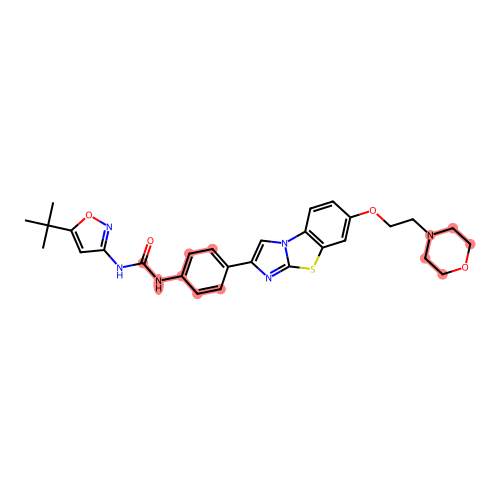

In [5]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display

def visualize_important_bits(smiles, bit_list, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)

    # Regenerate fingerprint WITH bit info so we know which atoms belong to which bit
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits, bitInfo=bit_info)

    # Collect the atoms involved in our top important bits
    highlight_atoms = set()
    highlight_bonds = set()

    for bit, _ in bit_list:
        if bit in bit_info:
            for atom_idx, atom_radius in bit_info[bit]:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, atom_radius, atom_idx)
                amap = {}
                submol = Chem.PathToSubmol(mol, env, atomMap=amap)
                highlight_atoms.update(amap.keys())
                for bond in env:
                    highlight_bonds.add(bond)

    drawer = rdMolDraw2D.MolDraw2DCairo(500, 500)
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(highlight_atoms),
        highlightBonds=list(highlight_bonds)
    )
    drawer.FinishDrawing()

    with open('important_substructure.png', 'wb') as f:
        f.write(drawer.GetDrawingText())

    return highlight_atoms

# Use the top 5 most important active bits for this molecule
top_bits = active_importances[:5]
highlighted = visualize_important_bits(example_smiles, top_bits)
print(f"Highlighted {len(highlighted)} atoms across top 5 important substructures")

# Display the image
from PIL import Image
img = Image.open('important_substructure.png')
display(img)

Predicted binding affinity (Y_log / pKd-like): 3.345
Highlighted 12 atoms across top 5 substructures


[05:02:55] DEPRECATION WARNING: please use MorganGenerator
[05:02:55] DEPRECATION WARNING: please use MorganGenerator


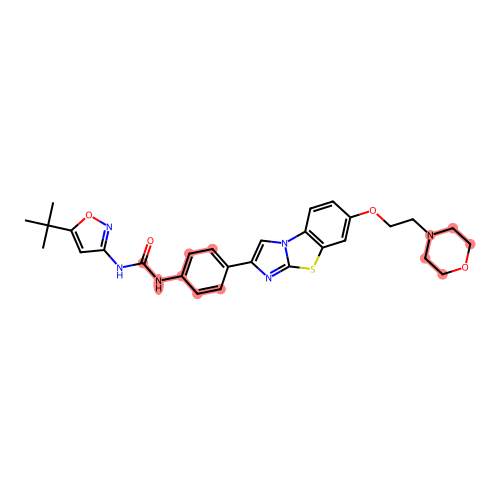

In [6]:
def explain_prediction(smiles, target_seq, model, top_n=5):
    """
    Given a molecule + protein, predict binding affinity AND show which
    substructures drove that prediction.
    """
    fp = smiles_to_fp(smiles)
    protein_feat = protein_to_features(target_seq)
    X_input = np.concatenate([fp, protein_feat]).reshape(1, -1)

    pred = model.predict(X_input)[0]

    importances = model.feature_importances_
    fp_importances = importances[:2048]
    active_bits = np.where(fp == 1)[0]
    active_importances = [(bit, fp_importances[bit]) for bit in active_bits]
    active_importances.sort(key=lambda x: x[1], reverse=True)
    top_bits = active_importances[:top_n]

    highlighted_atoms = visualize_important_bits(smiles, top_bits)

    print(f"Predicted binding affinity (Y_log / pKd-like): {pred:.3f}")
    print(f"Highlighted {len(highlighted_atoms)} atoms across top {top_n} substructures")

    img = Image.open('important_substructure.png')
    display(img)

    return pred, highlighted_atoms

# Test it on a different molecule to confirm it's fully reusable
test_smiles_2 = test['Drug'].iloc[5]
test_target_2 = test['Target'].iloc[5]
pred2, atoms2 = explain_prediction(test_smiles_2, test_target_2, model)